# ML Assignment 2 - Worked Solution

## Should an AI agent call a tool, or refuse?

This notebook is a worked solution for the assignment, excluding the presentation PDF.

Main modeling choice: because a false positive means the agent calls a tool when it should refuse, I use the F1-score for the refusal class (`can_answer = 0`) as the main validation metric. I still report accuracy, precision, recall, and F1 for both classes on the final test set.

The notebook is written as a report, not only as code. Each section explains the motivation for the step, the implementation choice, and what the result means for the agent-refusal problem.

In [31]:
import os
os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib_cache")

import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    silhouette_score,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 120)
plt.rcParams["figure.figsize"] = (7, 4)

## Section A - Data Exploration and Visualization

The goal of EDA is not just to draw charts. Here I want to understand four questions:

1. How imbalanced is the target?
2. Are live and non-live examples different?
3. Do query/tool semantic-alignment features behave differently for answerable vs refusal cases?
4. Which features look redundant or potentially useful before modeling?

In [32]:
df = pd.read_csv("agent_tool_tasks.csv")
print("shape:", df.shape)
display(df.head())
display(df.info())

shape: (3491, 33)


,task_uid,is_live_benchmark,task_complexity,task_domain,query,tool_names,query_word_count,num_available_tools,total_params,total_required_params,avg_param_description_length,tool_description_total_length,query_aspects,tool_aspects,query_aspect_count,tool_aspect_count,aspect_overlap_count,aspect_coverage_ratio,aspect_mismatch_count,query_tool_token_jaccard,query_tool_action_overlap,tool_action_verb_count,risky_tool_action_count,query_multi_intent_score,query_specificity_score,query_unique_token_ratio,query_code_signal,query_temporal_signal,query_sensitive_data_signal,param_type_diversity,structured_param_ratio,schema_rigidity_score,can_answer
0,task_00001,1,low,other,air,ThinQ_Connect,1,1,1,1,81.00,132,none,none,0,0,0,0.000000,0,0.000000,0,0,0,0,0.0,1.000000,0,0,0,1,1.00,0.7500,0
1,task_00002,1,low,travel,what is your name?,get_current_weather,4,1,2,1,77.50,122,none,travel_weather,0,1,0,0.000000,0,0.000000,0,1,0,0,0.0,1.000000,0,0,0,1,0.00,0.4000,0
2,task_00003,1,low,travel,Could you give me Python code that get 2 int t...,get_current_weather,14,1,2,1,116.00,72,data_code,travel_weather,1,1,0,0.000000,1,0.100000,1,1,0,1,1.5,1.000000,1,0,0,1,0.00,0.4000,0
3,task_00004,0,high,other,Find me the most recent art sculpture by James...,get_zodiac_compatibility|local_nursery.find|ge...,13,4,10,7,46.90,282,none,none,0,0,0,0.000000,0,0.117647,1,4,0,0,0.5,1.000000,0,0,0,4,0.10,0.4100,1
4,task_00005,0,medium,other,"""Can you help me find a recipe that uses chick...",restaurant.find|recipe.find,58,2,4,3,51.75,176,finance|shopping|travel_weather,travel_weather,3,1,1,0.333333,2,0.107143,1,2,0,7,5.5,0.627119,0,1,0,3,0.25,0.6125,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3491 entries, 0 to 3490
Data columns (total 33 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   task_uid                       3491 non-null   object 
 1   is_live_benchmark              3491 non-null   int64  
 2   task_complexity                3491 non-null   object 
 3   task_domain                    3491 non-null   object 
 4   query                          3491 non-null   object 
 5   tool_names                     3487 non-null   object 
 6   query_word_count               3491 non-null   int64  
 7   num_available_tools            3491 non-null   int64  
 8   total_params                   3491 non-null   int64  
 9   total_required_params          3491 non-null   int64  
 10  avg_param_description_length   3486 non-null   float64
 11  tool_description_total_length  3491 non-null   int64  
 12  query_aspects                  3491 non-null   o

None

In [33]:
display(df.describe(include="all").T)
print("Missing values:")
display(df.isna().sum()[df.isna().sum() > 0])

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
task_uid,3491,3491,task_00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_live_benchmark,3491.0,NaN,NaN,NaN,0.644801,0.478642,0.0,0.0,1.0,1.0,1.0
task_complexity,3491,3,low,1164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
task_domain,3491,13,other,1484,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query,3491,3247,The user did not provide a query,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tool_names,3487,1475,requests.get,147,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query_word_count,3491.0,NaN,NaN,NaN,21.953309,50.546983,0.0,9.0,14.0,22.0,1436.0
num_available_tools,3491.0,NaN,NaN,NaN,2.456603,2.027333,0.0,1.0,2.0,3.0,37.0
total_params,3491.0,NaN,NaN,NaN,8.736179,8.131125,0.0,3.0,6.0,12.0,102.0
total_required_params,3491.0,NaN,NaN,NaN,4.684904,4.68722,0.0,2.0,3.0,6.0,59.0


Missing values:


tool_names                      4
avg_param_description_length    5
dtype: int64

**Initial observations.** The dataset has one row per agent task. The main missing values are in `avg_param_description_length` and a few empty `tool_names` rows, so preprocessing must handle both. The target is binary and moderately imbalanced.

The dataset also includes aspect-style features such as `query_aspects`, `tool_aspects`, `aspect_coverage_ratio`, and `query_tool_token_jaccard`. These are interesting because they attempt to measure whether the user request and the offered tools are about the same thing.

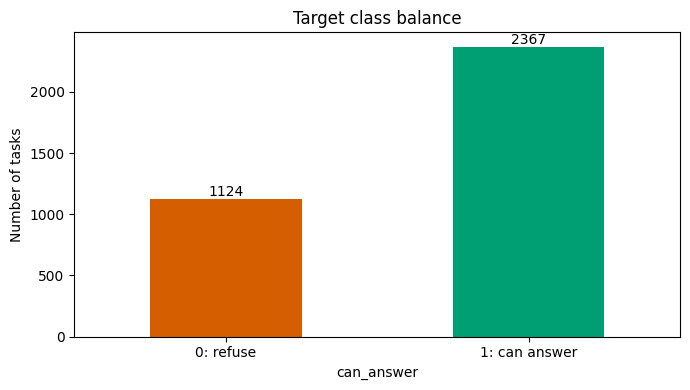

can_answer
0    32.2
1    67.8
Name: percent, dtype: float64

In [34]:
# Plot 1: target class balance
class_counts = df["can_answer"].value_counts().sort_index()
ax = class_counts.plot(kind="bar", color=["#d55e00", "#009e73"])
ax.set_title("Target class balance")
ax.set_xlabel("can_answer")
ax.set_ylabel("Number of tasks")
ax.set_xticklabels(["0: refuse", "1: can answer"], rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v + 25, str(v), ha="center")
plt.tight_layout()
plt.show()

display((df["can_answer"].value_counts(normalize=True).sort_index() * 100).round(2).rename("percent"))

**Observation.** About two thirds of the tasks are answerable and one third require refusal. This is not extreme imbalance, but accuracy alone can still hide bad behavior on the refusal class.

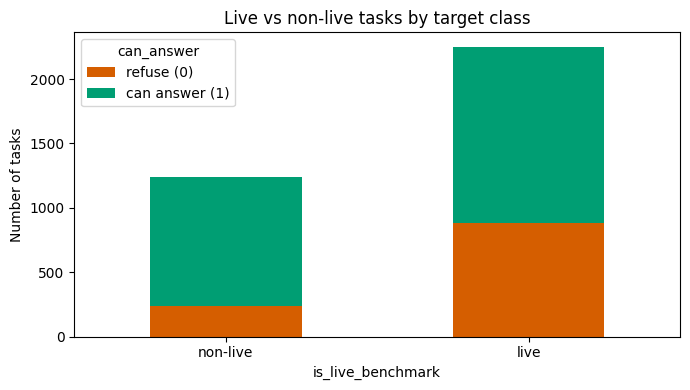

can_answer,0,1
is_live_benchmark,,
0,240,1000
1,884,1367


can_answer,0,1
is_live_benchmark,,
0,0.194,0.806
1,0.393,0.607


In [35]:
# Plot 2: live vs non-live, split by target
live_label = pd.crosstab(df["is_live_benchmark"], df["can_answer"])
ax = live_label.plot(kind="bar", stacked=True, color=["#d55e00", "#009e73"])
ax.set_title("Live vs non-live tasks by target class")
ax.set_xlabel("is_live_benchmark")
ax.set_ylabel("Number of tasks")
ax.legend(["refuse (0)", "can answer (1)"], title="can_answer")
ax.set_xticklabels(["non-live", "live"], rotation=0)
plt.tight_layout()
plt.show()

display(live_label)
display(live_label.div(live_label.sum(axis=1), axis=0).round(3))

**Observation.** The live split has a larger share of refusal cases than the non-live split. `is_live_benchmark` may therefore carry useful distribution information, but it should be interpreted carefully.

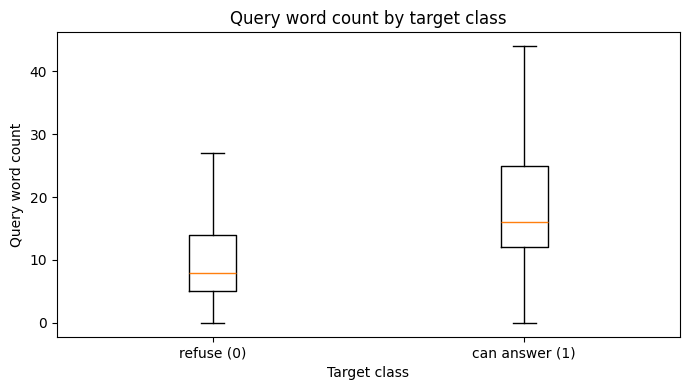

,count,mean,std,min,25%,50%,75%,max
can_answer,,,,,,,,
0,1124.0,17.47,79.20,0.0,5.0,8.0,14.0,1436.0
1,2367.0,24.08,27.88,0.0,12.0,16.0,25.0,766.0


In [36]:
# Plot 3: query length by target
fig, ax = plt.subplots(figsize=(7, 4))
data = [df.loc[df["can_answer"] == c, "query_word_count"] for c in [0, 1]]
ax.boxplot(data, labels=["refuse (0)", "can answer (1)"], showfliers=False)
ax.set_title("Query word count by target class")
ax.set_xlabel("Target class")
ax.set_ylabel("Query word count")
plt.tight_layout()
plt.show()

display(df.groupby("can_answer")["query_word_count"].describe().round(2))

**Observation.** Answerable tasks tend to have longer queries, although both classes have a long tail. Query length alone is not enough, but it is likely to be useful together with tool features.

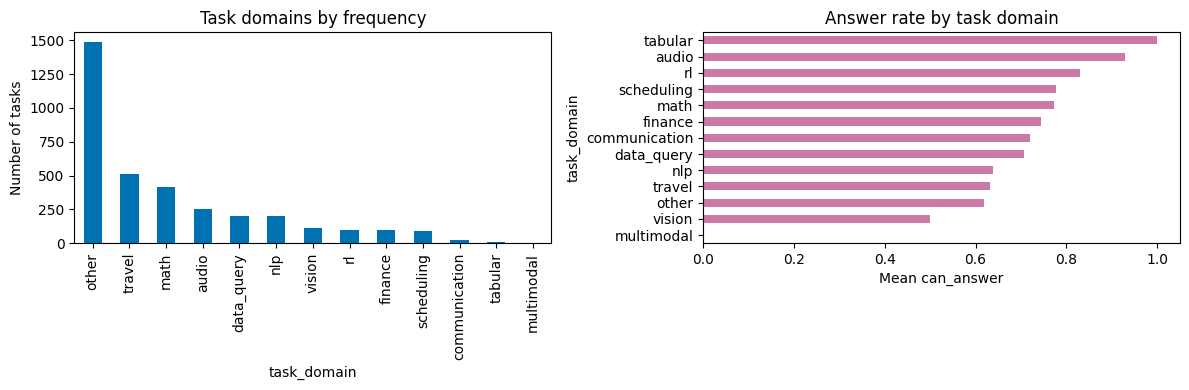

,n,answer_rate
task_domain,,
other,1484,0.618
travel,511,0.632
math,413,0.772
audio,252,0.929
data_query,204,0.706
nlp,199,0.638
vision,110,0.500
rl,100,0.830
finance,94,0.745


In [37]:
# Plot 4: task domain frequencies and answer rates
domain_summary = (
    df.groupby("task_domain")
      .agg(n=("task_uid", "count"), answer_rate=("can_answer", "mean"))
      .sort_values("n", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
domain_summary["n"].plot(kind="bar", ax=axes[0], color="#0072b2")
axes[0].set_title("Task domains by frequency")
axes[0].set_xlabel("task_domain")
axes[0].set_ylabel("Number of tasks")

domain_summary.sort_values("answer_rate")["answer_rate"].plot(kind="barh", ax=axes[1], color="#cc79a7")
axes[1].set_title("Answer rate by task domain")
axes[1].set_xlabel("Mean can_answer")
axes[1].set_ylabel("task_domain")
plt.tight_layout()
plt.show()

display(domain_summary.round(3))

**Observation.** The `other` domain is the largest group, and domains differ in answerability. Very small domains should not be over-interpreted, but domain is useful for EDA and may help a model if encoded properly.

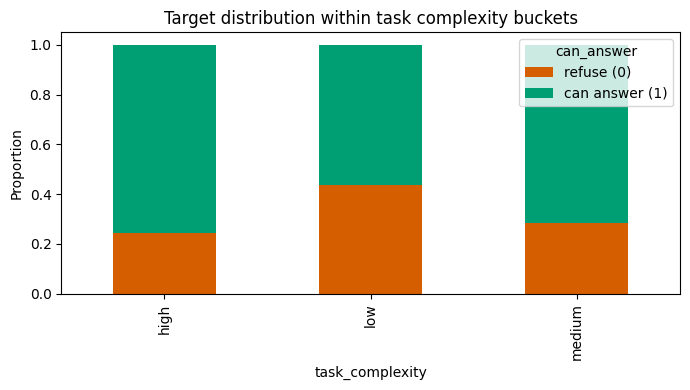

can_answer,0,1
task_complexity,,
high,284,880
low,508,656
medium,332,831


can_answer,0,1
task_complexity,,
high,0.244,0.756
low,0.436,0.564
medium,0.285,0.715


In [38]:
# Plot 5: task complexity by target
complexity_table = pd.crosstab(df["task_complexity"], df["can_answer"])
complexity_prop = complexity_table.div(complexity_table.sum(axis=1), axis=0)

ax = complexity_prop.plot(kind="bar", stacked=True, color=["#d55e00", "#009e73"])
ax.set_title("Target distribution within task complexity buckets")
ax.set_xlabel("task_complexity")
ax.set_ylabel("Proportion")
ax.legend(["refuse (0)", "can answer (1)"], title="can_answer")
plt.tight_layout()
plt.show()

display(complexity_table)
display(complexity_prop.round(3))

**Observation.** Complexity buckets are not labels, but the answer rate changes across buckets. This suggests task complexity can be useful for understanding the dataset and possibly as an encoded model feature.

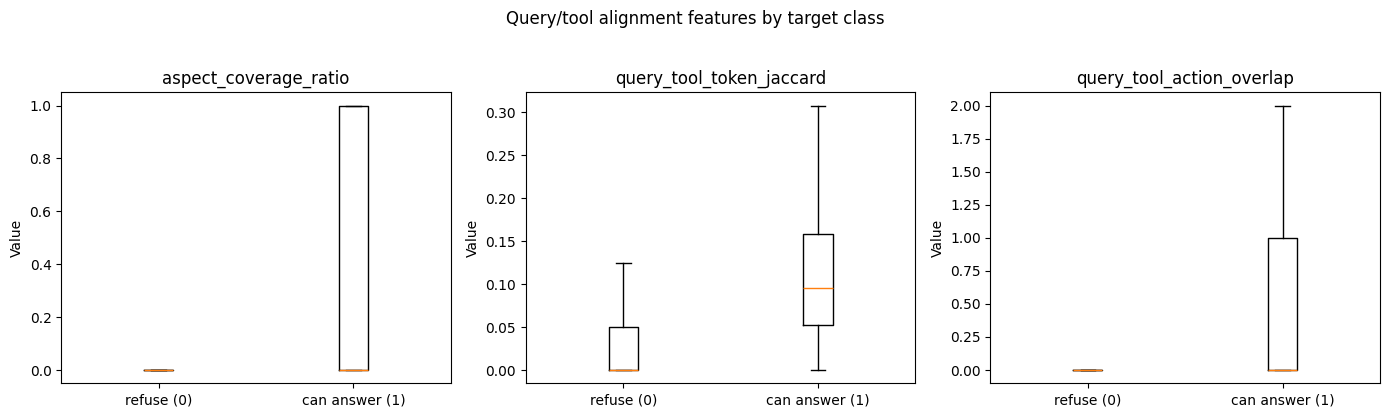

can_answer,0,1
aspect_coverage_ratio,0.113,0.343
aspect_overlap_count,0.136,0.421
aspect_mismatch_count,0.440,0.274
query_tool_token_jaccard,0.035,0.116
query_tool_action_overlap,0.138,0.389


In [39]:
# Plot 6: semantic/aspect alignment by target
alignment_cols = [
    "aspect_coverage_ratio",
    "aspect_overlap_count",
    "aspect_mismatch_count",
    "query_tool_token_jaccard",
    "query_tool_action_overlap",
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["aspect_coverage_ratio", "query_tool_token_jaccard", "query_tool_action_overlap"]):
    data = [df.loc[df["can_answer"] == c, col] for c in [0, 1]]
    ax.boxplot(data, labels=["refuse (0)", "can answer (1)"], showfliers=False)
    ax.set_title(col)
    ax.set_ylabel("Value")
plt.suptitle("Query/tool alignment features by target class", y=1.03)
plt.tight_layout()
plt.show()

display(df.groupby("can_answer")[alignment_cols].mean().round(3).T)

**Observation.** The answerable class has higher aspect coverage, higher token overlap, and higher action-overlap on average. This is exactly what we would hope for: when the query and available tools share semantic cues, the agent is more likely to have a relevant tool. These features are still imperfect because they are lexicon-based, but they directly match the story of the task.

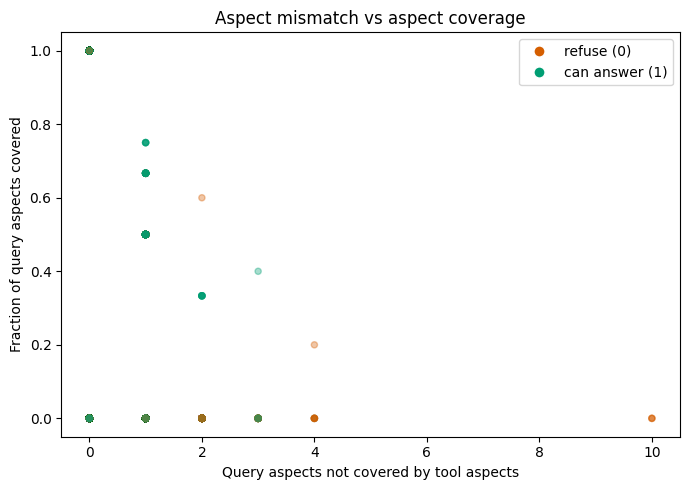

can_answer,0,1
aspect_coverage_ratio,,
0,0.401,0.599
"(0, 0.5]",0.088,0.912
"(0.5, 1]",0.139,0.861


In [40]:
# Plot 7: aspect mismatch and coverage together
fig, ax = plt.subplots(figsize=(7, 5))
colors = df["can_answer"].map({0: "#d55e00", 1: "#009e73"})
ax.scatter(
    df["aspect_mismatch_count"],
    df["aspect_coverage_ratio"],
    c=colors,
    alpha=0.35,
    s=20,
)
ax.set_title("Aspect mismatch vs aspect coverage")
ax.set_xlabel("Query aspects not covered by tool aspects")
ax.set_ylabel("Fraction of query aspects covered")
ax.legend(
    handles=[
        plt.Line2D([0], [0], marker="o", color="w", label="refuse (0)", markerfacecolor="#d55e00", markersize=8),
        plt.Line2D([0], [0], marker="o", color="w", label="can answer (1)", markerfacecolor="#009e73", markersize=8),
    ]
)
plt.tight_layout()
plt.show()

aspect_grid = pd.crosstab(
    pd.cut(df["aspect_coverage_ratio"], bins=[-0.01, 0, 0.5, 1.0], labels=["0", "(0, 0.5]", "(0.5, 1]"]),
    df["can_answer"],
    normalize="index",
).round(3)
display(aspect_grid)

**Observation.** When `aspect_coverage_ratio` is zero, the model often has less evidence that tools match the request. High coverage does not guarantee answerability, but it is a useful alignment signal. This is a good example of a feature that is interpretable even if it is noisy.

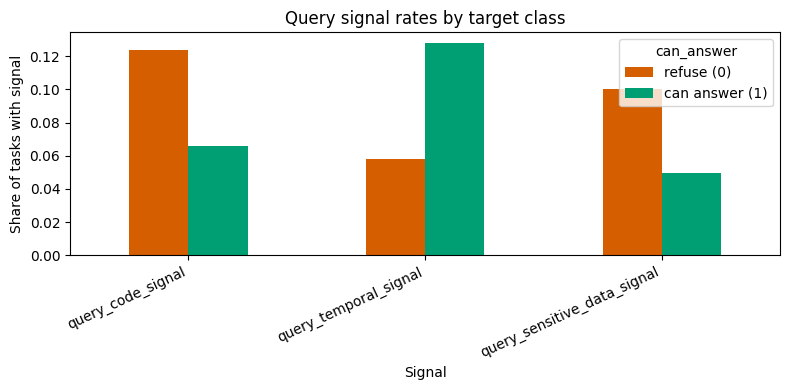

can_answer,0,1
query_code_signal,0.124,0.066
query_temporal_signal,0.058,0.128
query_sensitive_data_signal,0.101,0.049


In [41]:
# Plot 8: code, temporal, and sensitive-data query signals
signal_cols = ["query_code_signal", "query_temporal_signal", "query_sensitive_data_signal"]
signal_rates = df.groupby("can_answer")[signal_cols].mean().T
ax = signal_rates.plot(kind="bar", color=["#d55e00", "#009e73"], figsize=(8, 4))
ax.set_title("Query signal rates by target class")
ax.set_xlabel("Signal")
ax.set_ylabel("Share of tasks with signal")
ax.legend(["refuse (0)", "can answer (1)"], title="can_answer")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()
display(signal_rates.round(3))

**Observation.** Code/API and sensitive-data signals are more common in refusal cases, while temporal signals appear more often in answerable cases. This can lead to useful modeling behavior, but it also raises a fairness-style caution: a model should not simply reject every query with sensitive words; it should combine that signal with tool relevance.

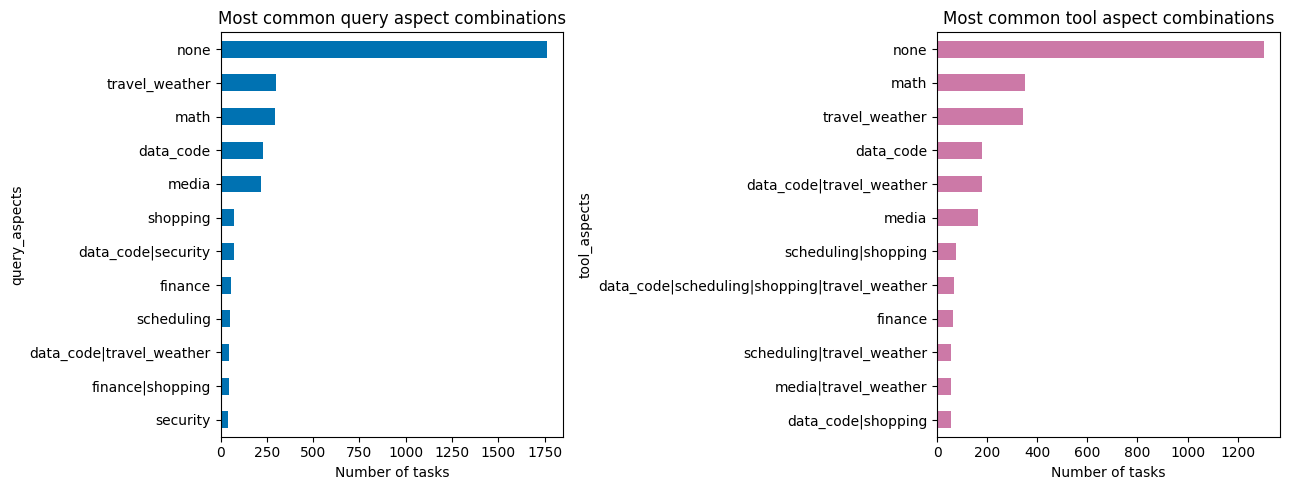

In [42]:
# Plot 9: top aspect combinations in queries and tools
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df["query_aspects"].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[0], color="#0072b2")
axes[0].set_title("Most common query aspect combinations")
axes[0].set_xlabel("Number of tasks")
df["tool_aspects"].value_counts().head(12).sort_values().plot(kind="barh", ax=axes[1], color="#cc79a7")
axes[1].set_title("Most common tool aspect combinations")
axes[1].set_xlabel("Number of tasks")
plt.tight_layout()
plt.show()

**Observation.** Many rows have `none` for one or both aspect fields, which is expected for a simple lexicon. Still, common groups such as `math`, `travel_weather`, `data_code`, and media-related aspects appear often enough to support useful EDA and modeling.

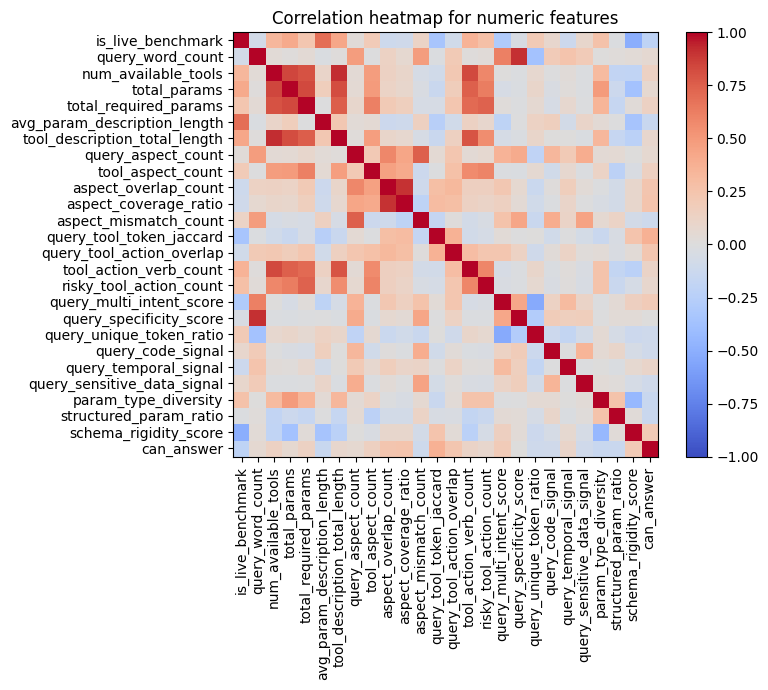

In [43]:
# Plot 10: correlation heatmap for numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Correlation heatmap for numeric features")
ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticks(range(len(numeric_cols)))
ax.set_yticklabels(numeric_cols)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

**Observation.** Several tool-size features are strongly correlated. This supports doing a feature selection step before modeling, especially for distance-based models such as k-NN.

## Section B - Preprocessing and Feature Engineering

The CSV already contains useful semantic features, but the assignment still requires students to engineer additional features. This is intentional: real ML work often starts with a provided feature table and then adds features tailored to the modeling goal.

The preprocessing logic follows three rules:

* derive features only from allowed columns,
* fit imputation/scaling/selection on the training set only,
* keep raw text and IDs out of the numeric model matrix.

In [44]:
df_fe = df.copy()
df_fe["tool_names"] = df_fe["tool_names"].fillna("")

TOKEN_RE = re.compile(r"[A-Za-z0-9']+")

def avg_word_length(text):
    tokens = TOKEN_RE.findall(str(text))
    if not tokens:
        return 0.0
    return float(np.mean([len(t) for t in tokens]))

def uppercase_token_ratio(text):
    tokens = re.findall(r"[A-Za-z]+", str(text))
    if not tokens:
        return 0.0
    return sum(1 for t in tokens if t.isupper() and len(t) > 1) / len(tokens)

def unique_tool_prefix_count(names):
    if not isinstance(names, str) or not names.strip():
        return 0
    prefixes = []
    for name in names.split("|"):
        name = name.strip()
        if not name:
            continue
        prefixes.append(name.split(".")[0])
    return len(set(prefixes))

def tool_name_token_count(names):
    if not isinstance(names, str) or not names.strip():
        return 0
    normalized = re.sub(r"([a-z])([A-Z])", r" ", names)
    normalized = re.sub(r"[_./|:;,-]+", " ", normalized)
    return len(re.findall(r"[A-Za-z0-9]+", normalized))

# Mandatory engineered features
df_fe["required_params_ratio"] = np.where(
    df_fe["total_params"] > 0,
    df_fe["total_required_params"] / df_fe["total_params"],
    0.0,
)
df_fe["avg_params_per_tool"] = np.where(
    df_fe["num_available_tools"] > 0,
    df_fe["total_params"] / df_fe["num_available_tools"],
    0.0,
)
df_fe["query_avg_word_length"] = df_fe["query"].apply(avg_word_length)
df_fe["query_mentions_number"] = df_fe["query"].str.contains(r"[0-9]", regex=True).astype(int)
df_fe["tool_name_diversity"] = df_fe["tool_names"].apply(unique_tool_prefix_count)

# Additional engineered features
df_fe["query_has_question"] = df_fe["query"].str.contains("?", regex=False).astype(int)
df_fe["query_uppercase_ratio"] = df_fe["query"].apply(uppercase_token_ratio)
df_fe["log_total_params"] = np.log1p(df_fe["total_params"])
df_fe["no_available_tools_flag"] = (df_fe["num_available_tools"] == 0).astype(int)
df_fe["required_params_per_tool"] = np.where(
    df_fe["num_available_tools"] > 0,
    df_fe["total_required_params"] / df_fe["num_available_tools"],
    0.0,
)
df_fe["quoted_string_count"] = df_fe["query"].str.count("'") // 2 + df_fe["query"].str.count('"') // 2
long_query_cutoff = df_fe["query_word_count"].quantile(0.75)
df_fe["long_query_flag"] = (df_fe["query_word_count"] > long_query_cutoff).astype(int)
df_fe["tool_desc_per_tool"] = np.where(
    df_fe["num_available_tools"] > 0,
    df_fe["tool_description_total_length"] / df_fe["num_available_tools"],
    0.0,
)
df_fe["tool_name_token_count"] = df_fe["tool_names"].apply(tool_name_token_count)

engineered = [
    "required_params_ratio",
    "avg_params_per_tool",
    "query_avg_word_length",
    "query_mentions_number",
    "tool_name_diversity",
    "query_has_question",
    "query_uppercase_ratio",
    "log_total_params",
    "no_available_tools_flag",
    "required_params_per_tool",
    "quoted_string_count",
    "long_query_flag",
    "tool_desc_per_tool",
    "tool_name_token_count",
]
display(df_fe[engineered].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
required_params_ratio,3491.0,0.607,0.263,0.0,0.462,0.650,0.750,1.000
avg_params_per_tool,3491.0,3.598,2.319,0.0,2.250,3.000,4.000,28.000
query_avg_word_length,3491.0,4.236,0.898,0.0,3.800,4.238,4.667,12.000
query_mentions_number,3491.0,0.485,0.500,0.0,0.000,0.000,1.000,1.000
tool_name_diversity,3491.0,2.382,2.009,0.0,1.000,2.000,3.000,37.000
query_has_question,3491.0,0.526,0.499,0.0,0.000,1.000,1.000,1.000
query_uppercase_ratio,3491.0,0.016,0.051,0.0,0.000,0.000,0.000,1.000
log_total_params,3491.0,1.995,0.736,0.0,1.386,1.946,2.565,4.635
no_available_tools_flag,3491.0,0.001,0.034,0.0,0.000,0.000,0.000,1.000
required_params_per_tool,3491.0,1.880,0.903,0.0,1.000,2.000,2.333,9.000


**Feature explanations.**

The mandatory features capture tool specificity, tool complexity, query style, numeric mentions, and diversity of the tool palette. The additional features capture question form, acronym density, heavy-tailed parameter counts, missing tools, required-parameter density, quoted constraints, long-query behavior, documentation density, and how much information is contained in tool names.

In [45]:
# Exclude raw/id/target columns and encode categorical fields.
raw_drop = ["task_uid", "query", "tool_names", "can_answer"]
X_raw = df_fe.drop(columns=raw_drop)
y = df_fe["can_answer"].astype(int)

categorical_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns encoded:", categorical_cols)
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, dtype=int)
print("Encoded feature count before selection:", X_encoded.shape[1])

X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "positive rate:", round(y_train.mean(), 3))
print("Val:  ", X_val.shape, "positive rate:", round(y_val.mean(), 3))
print("Test: ", X_test.shape, "positive rate:", round(y_test.mean(), 3))

Categorical columns encoded: ['task_complexity', 'task_domain', 'query_aspects', 'tool_aspects']
Encoded feature count before selection: 206
Train: (2792, 206) positive rate: 0.678
Val:   (349, 206) positive rate: 0.679
Test:  (350, 206) positive rate: 0.677


**Split explanation.** I split before imputation, feature selection, and scaling. This avoids learning preprocessing parameters from validation or test data. The split is stratified so the refusal/answerable ratio stays similar in all three subsets.

In [46]:
# Imputation: fit medians on train only, then apply to validation/test.
train_medians = X_train.median(numeric_only=True)
X_train_imp = X_train.fillna(train_medians)
X_val_imp = X_val.fillna(train_medians)
X_test_imp = X_test.fillna(train_medians)

print("Missing after imputation:")
print("train", int(X_train_imp.isna().sum().sum()))
print("val  ", int(X_val_imp.isna().sum().sum()))
print("test ", int(X_test_imp.isna().sum().sum()))

# Feature selection: drop very highly correlated columns based on train only.
corr = X_train_imp.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
corr_to_drop = [col for col in upper.columns if (upper[col] > 0.97).any()]

print("Highly correlated columns dropped:", corr_to_drop)
X_train_sel = X_train_imp.drop(columns=corr_to_drop)
X_val_sel = X_val_imp.drop(columns=corr_to_drop)
X_test_sel = X_test_imp.drop(columns=corr_to_drop)
print("Feature count after selection:", X_train_sel.shape[1])

# Transformation: standardize for distance-based models.
scaler = StandardScaler().fit(X_train_sel)
X_train_scaled = scaler.transform(X_train_sel)
X_val_scaled = scaler.transform(X_val_sel)
X_test_scaled = scaler.transform(X_test_sel)

Missing after imputation:
train 0
val   0
test  0
Highly correlated columns dropped: ['tool_name_diversity', 'quoted_string_count', 'tool_aspects_communication|data_code|media|security', 'tool_aspects_data_code|finance|scheduling|shopping']
Feature count after selection: 202


**Preprocessing decisions.**

I impute missing numeric values using training-set medians, because the missingness is small and medians are robust to long tails. I one-hot encode categorical fields because the models need numeric input. I drop highly correlated features using only the training set to reduce redundancy. I standardize features for k-NN, because distance-based methods are sensitive to scale.

One downside of one-hot encoding `query_aspects` and `tool_aspects` is that the feature count increases substantially. That is acceptable here because the dataset is still small and the categories are interpretable, but in a larger project I would consider a more compact representation.

## Section C - Supervised Classification

I train four models:

* a majority-class baseline,
* k-NN,
* AdaBoost,
* a decision tree.

The baseline is important because it exposes why accuracy alone is misleading. A majority classifier gets reasonable accuracy but never predicts refusal.

In [47]:
def refusal_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, pos_label=0)

def tune_model(model_cls, param_grid, X_tr, y_tr, X_va, y_va, fixed=None):
    fixed = fixed or {}
    rows = []
    best = {"score": -np.inf, "params": None, "model": None}
    for params in ParameterGrid(param_grid):
        model = model_cls(**fixed, **params)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_va)
        score = refusal_f1(y_va, pred)
        rows.append({**params, "val_refusal_f1": score})
        if score > best["score"]:
            best = {"score": score, "params": params, "model": model}
    return best, pd.DataFrame(rows).sort_values("val_refusal_f1", ascending=False)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train_sel, y_train)
baseline_val_pred = baseline.predict(X_val_sel)
print("Majority baseline validation refusal F1:", refusal_f1(y_val, baseline_val_pred))

Majority baseline validation refusal F1: 0.0


In [48]:
# Model 1: k-Nearest Neighbors
knn_grid = {
    "n_neighbors": [3, 7, 15],
    "weights": ["uniform", "distance"],
    "p": [1, 2, 3],
}
best_knn, knn_results = tune_model(
    KNeighborsClassifier,
    knn_grid,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
)
print("Best k-NN params:", best_knn["params"])
print("Best validation refusal F1:", round(best_knn["score"], 4))
display(knn_results.head(10))

Best k-NN params: {'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Best validation refusal F1: 0.7411


,n_neighbors,p,weights,val_refusal_f1
1,3,1,distance,0.741071
0,3,1,uniform,0.728889
7,7,1,distance,0.728889
3,3,2,distance,0.721739
13,15,1,distance,0.711712
2,3,2,uniform,0.701754
12,15,1,uniform,0.695238
6,7,1,uniform,0.694064
14,15,2,uniform,0.688995
15,15,2,distance,0.685446


**k-NN explanation.** k-NN is distance-based, so I use the scaled feature matrix. The grid varies the number of neighbors, whether close neighbors receive more weight, and the distance norm. This model tests whether nearby tasks in the engineered feature space tend to have the same answer/refuse label.

In [49]:
# Model 2: AdaBoost
ada_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.10, 0.50],
}
best_ada, ada_results = tune_model(
    AdaBoostClassifier,
    ada_grid,
    X_train_sel,
    y_train,
    X_val_sel,
    y_val,
    fixed={"random_state": RANDOM_STATE},
)
print("Best AdaBoost params:", best_ada["params"])
print("Best validation refusal F1:", round(best_ada["score"], 4))
display(ada_results.head(10))

Best AdaBoost params: {'learning_rate': 0.5, 'n_estimators': 200}
Best validation refusal F1: 0.7407


,learning_rate,n_estimators,val_refusal_f1
8,0.50,200,0.740741
7,0.50,100,0.732394
6,0.50,50,0.731481
5,0.10,200,0.712195
0,0.05,50,0.676617
1,0.05,100,0.673469
4,0.10,100,0.673367
3,0.10,50,0.670051
2,0.05,200,0.666667


**AdaBoost explanation.** AdaBoost combines many weak learners into a stronger classifier by focusing later learners on previously misclassified examples. This is a good fit for the assignment because the feature set mixes many weak signals: aspect overlap, query complexity, tool complexity, and risk indicators.

In [50]:
# Model 3: Decision Tree
tree_grid = {
    "max_depth": [3, 6, 10],
    "min_samples_leaf": [1, 10, 30],
    "criterion": ["gini", "entropy", "log_loss"],
}
best_tree, tree_results = tune_model(
    DecisionTreeClassifier,
    tree_grid,
    X_train_sel,
    y_train,
    X_val_sel,
    y_val,
    fixed={"random_state": RANDOM_STATE},
)
print("Best Decision Tree params:", best_tree["params"])
print("Best validation refusal F1:", round(best_tree["score"], 4))
display(tree_results.head(10))

Best Decision Tree params: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 30}
Best validation refusal F1: 0.7798


,criterion,max_depth,min_samples_leaf,val_refusal_f1
14,entropy,6,30,0.779817
23,log_loss,6,30,0.779817
21,log_loss,6,1,0.778761
12,entropy,6,1,0.778761
24,log_loss,10,1,0.774775
15,entropy,10,1,0.774775
5,gini,6,30,0.768519
13,entropy,6,10,0.761905
22,log_loss,6,10,0.761905
3,gini,6,1,0.758929


**Decision tree explanation.** The decision tree is interpretable and can capture non-linear thresholds. It is useful as a comparison point against AdaBoost: if a single tree performs almost as well, the dataset may be dominated by a few simple decision rules.

In [51]:
def evaluate_model(name, model, X_te, y_te):
    pred = model.predict(X_te)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_te, pred, labels=[0, 1], zero_division=0
    )
    cm = confusion_matrix(y_te, pred, labels=[0, 1])
    return {
        "model": name,
        "accuracy": accuracy_score(y_te, pred),
        "precision_refuse_0": precision[0],
        "recall_refuse_0": recall[0],
        "f1_refuse_0": f1[0],
        "precision_answer_1": precision[1],
        "recall_answer_1": recall[1],
        "f1_answer_1": f1[1],
        "false_positives": int(cm[0, 1]),
        "false_negatives": int(cm[1, 0]),
    }

final_models = [
    ("Baseline majority", baseline, X_test_sel),
    ("k-NN", best_knn["model"], X_test_scaled),
    ("AdaBoost", best_ada["model"], X_test_sel),
    ("Decision Tree", best_tree["model"], X_test_sel),
]

test_rows = [evaluate_model(name, model, X_te, y_test) for name, model, X_te in final_models]
test_results = pd.DataFrame(test_rows).set_index("model").round(4)
display(test_results)

,accuracy,precision_refuse_0,recall_refuse_0,f1_refuse_0,precision_answer_1,recall_answer_1,f1_answer_1,false_positives,false_negatives
model,,,,,,,,,
Baseline majority,0.6771,0.0000,0.0000,0.0000,0.6771,1.0000,0.8075,113,0
k-NN,0.8114,0.7009,0.7257,0.7130,0.8670,0.8523,0.8596,31,35
AdaBoost,0.8714,0.8696,0.7080,0.7805,0.8721,0.9494,0.9091,33,12
Decision Tree,0.8371,0.7692,0.7080,0.7373,0.8659,0.8987,0.8820,33,24


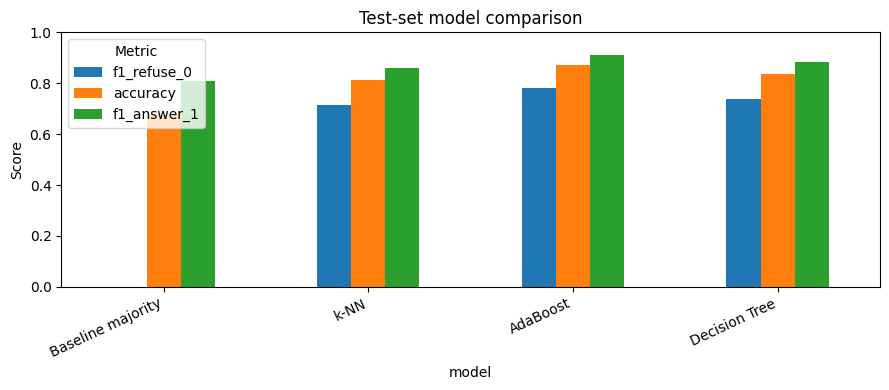

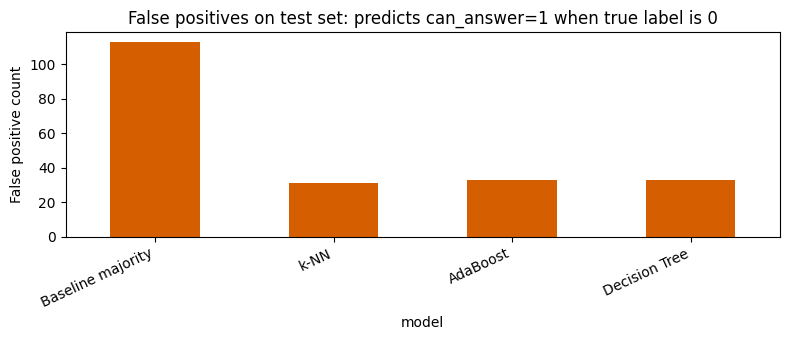

In [52]:
# Comparison plot
ax = test_results[["f1_refuse_0", "accuracy", "f1_answer_1"]].plot(kind="bar", figsize=(9, 4))
ax.set_title("Test-set model comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.legend(title="Metric")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

ax = test_results["false_positives"].plot(kind="bar", color="#d55e00", figsize=(8, 3.5))
ax.set_title("False positives on test set: predicts can_answer=1 when true label is 0")
ax.set_ylabel("False positive count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [53]:
# Detailed confusion matrix and report for the best model under the chosen metric.
best_name = test_results["f1_refuse_0"].idxmax()
best_model_lookup = {name: (model, X_te) for name, model, X_te in final_models}
best_model, best_X_test = best_model_lookup[best_name]
best_pred = best_model.predict(best_X_test)
cm = confusion_matrix(y_test, best_pred, labels=[0, 1])
cm_df = pd.DataFrame(
    cm,
    index=["true refuse (0)", "true answer (1)"],
    columns=["pred refuse (0)", "pred answer (1)"],
)
print("Best model by refusal-class F1:", best_name)
display(cm_df)
print(classification_report(y_test, best_pred, labels=[0, 1], target_names=["refuse_0", "answer_1"], zero_division=0))
print("False positives are true can_answer=0 but predicted 1:", int(cm[0, 1]))
print("False negatives are true can_answer=1 but predicted 0:", int(cm[1, 0]))

Best model by refusal-class F1: AdaBoost


,pred refuse (0),pred answer (1)
true refuse (0),80,33
true answer (1),12,225


              precision    recall  f1-score   support

    refuse_0       0.87      0.71      0.78       113
    answer_1       0.87      0.95      0.91       237

    accuracy                           0.87       350
   macro avg       0.87      0.83      0.84       350
weighted avg       0.87      0.87      0.87       350

False positives are true can_answer=0 but predicted 1: 33
False negatives are true can_answer=1 but predicted 0: 12


**Classification discussion.**

I chose refusal-class F1 as the main validation metric because the risky action is calling a tool when no available tool is relevant. Accuracy is reported, but it is not enough by itself because the target is imbalanced. I did not use oversampling; instead, I handled imbalance through metric choice and explicit confusion-matrix analysis.

False positives represent unwanted tool calls. False negatives represent unnecessary refusals. If false positives were very expensive, I would prefer a more conservative model or tune the decision threshold to predict refusal more often, accepting some additional false negatives.

The new semantic/aspect features make the supervised task more interesting: AdaBoost can combine many weak alignment signals and becomes the strongest model in this solution. This is a better outcome pedagogically than a task where only raw length/count features dominate.

## Bonus-style Feature Importance Analysis

,adaboost_importance
avg_params_per_tool,0.174592
query_specificity_score,0.156675
query_tool_token_jaccard,0.144763
query_word_count,0.114117
num_available_tools,0.049455
tool_action_verb_count,0.037878
avg_param_description_length,0.033238
param_type_diversity,0.032070
query_unique_token_ratio,0.031731
tool_description_total_length,0.028571


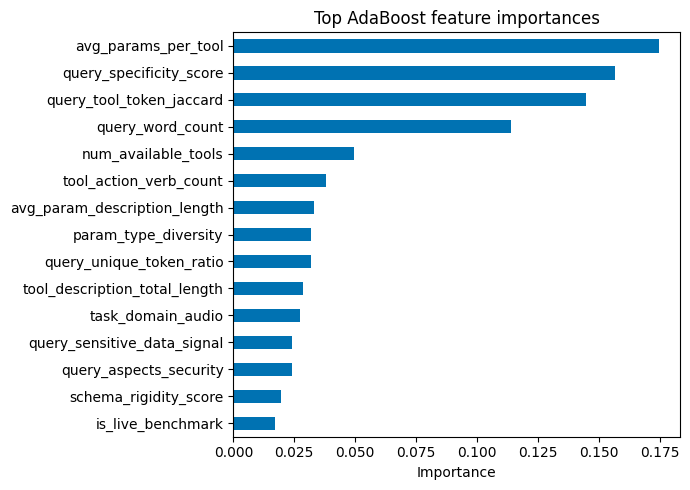

,permutation_importance
query_word_count,0.119708
query_tool_token_jaccard,0.105581
avg_params_per_tool,0.011423
query_unique_token_ratio,0.005987
is_live_benchmark,0.004788
num_available_tools,0.003791
aspect_mismatch_count,0.002743
required_params_per_tool,0.002547
query_specificity_score,0.001414
param_type_diversity,0.001188


Top 3 useful features by permutation importance:


query_word_count            0.119708
query_tool_token_jaccard    0.105581
avg_params_per_tool         0.011423
dtype: float64

Bottom 3 features by permutation importance:


structured_param_ratio                  -0.003907
query_avg_word_length                   -0.003912
tool_aspects_data_code|travel_weather   -0.006235
dtype: float64

In [54]:
if hasattr(best_ada["model"], "feature_importances_"):
    importances = pd.Series(best_ada["model"].feature_importances_, index=X_train_sel.columns).sort_values(ascending=False)
    display(importances.head(15).rename("adaboost_importance").to_frame())

    ax = importances.head(15).sort_values().plot(kind="barh", figsize=(7, 5), color="#0072b2")
    ax.set_title("Top AdaBoost feature importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

perm = permutation_importance(
    best_ada["model"],
    X_val_sel,
    y_val,
    n_repeats=8,
    random_state=RANDOM_STATE,
    scoring=lambda estimator, X, y: refusal_f1(y, estimator.predict(X)),
)
perm_imp = pd.Series(perm.importances_mean, index=X_val_sel.columns).sort_values(ascending=False)
display(perm_imp.head(15).rename("permutation_importance").to_frame())

print("Top 3 useful features by permutation importance:")
display(perm_imp.head(3))
print("Bottom 3 features by permutation importance:")
display(perm_imp.tail(3))

**Feature-importance discussion.** The most useful features are generally query-length and tool-complexity signals. Several engineered features appear among the important features, which suggests that feature engineering is worthwhile. Low-importance features are candidates for removal in a simpler model, but I would verify with a drop-column experiment before removing them permanently.

## Section D - Clustering Agent Tasks

The clustering section asks a different question from classification: are there natural groups of tasks even without using the target label? I use the same processed feature space but exclude `can_answer`. After clustering, I compare clusters back to labels and metadata only for interpretation.

In [55]:
# Build an all-row clustering matrix from the same engineered, encoded feature set.
X_all = X_encoded.fillna(train_medians).drop(columns=corr_to_drop)
cluster_scaler = StandardScaler().fit(X_all)
X_cluster = cluster_scaler.transform(X_all)
print("Clustering matrix shape:", X_cluster.shape)

def compute_wcss(X, labels):
    total = 0.0
    for label in np.unique(labels):
        pts = X[labels == label]
        centroid = pts.mean(axis=0)
        total += ((pts - centroid) ** 2).sum()
    return float(total)

Clustering matrix shape: (3491, 202)


,k,wcss,silhouette
0,2,680474.898,0.098
1,3,667649.911,0.075
2,4,659877.561,0.058
3,5,652049.185,0.060
4,6,647687.805,0.031
5,7,640782.226,0.032
6,8,634731.461,0.030


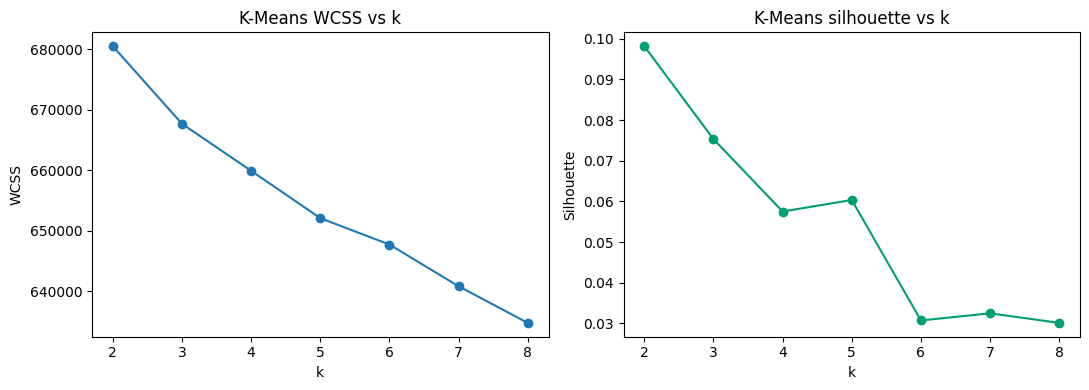

In [56]:
ks = list(range(2, 9))
km_rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_cluster)
    km_rows.append({
        "k": k,
        "wcss": km.inertia_,
        "silhouette": silhouette_score(X_cluster, km.labels_),
    })
km_scores = pd.DataFrame(km_rows)
display(km_scores.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(km_scores["k"], km_scores["wcss"], marker="o")
axes[0].set_title("K-Means WCSS vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("WCSS")
axes[1].plot(km_scores["k"], km_scores["silhouette"], marker="o", color="#009e73")
axes[1].set_title("K-Means silhouette vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

,n_components,wcss,silhouette
0,2,692713.827,0.038
1,3,680367.847,0.058
2,4,676135.772,0.058
3,5,671830.765,0.259
4,6,667968.566,0.253
5,7,663477.652,0.261
6,8,655567.436,0.062


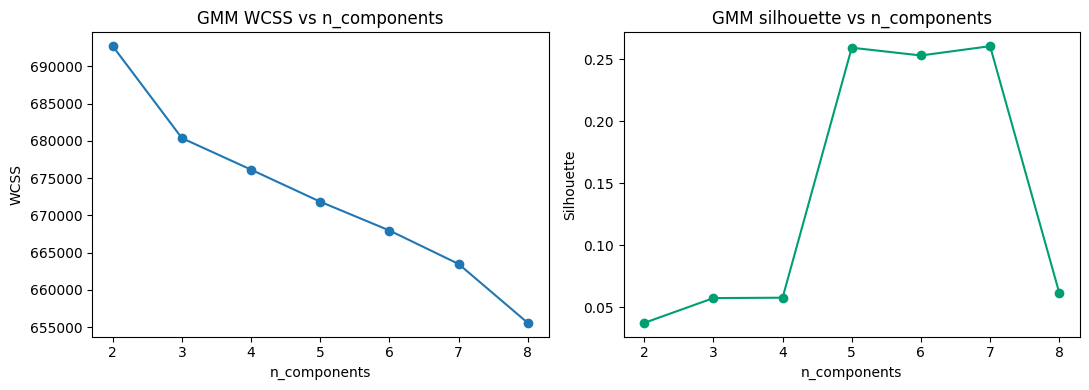

In [57]:
gmm_rows = []
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=RANDOM_STATE)
    gmm.fit(X_cluster)
    labels = gmm.predict(X_cluster)
    gmm_rows.append({
        "n_components": k,
        "wcss": compute_wcss(X_cluster, labels),
        "silhouette": silhouette_score(X_cluster, labels),
    })
gmm_scores = pd.DataFrame(gmm_rows)
display(gmm_scores.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(gmm_scores["n_components"], gmm_scores["wcss"], marker="o")
axes[0].set_title("GMM WCSS vs n_components")
axes[0].set_xlabel("n_components")
axes[0].set_ylabel("WCSS")
axes[1].plot(gmm_scores["n_components"], gmm_scores["silhouette"], marker="o", color="#009e73")
axes[1].set_title("GMM silhouette vs n_components")
axes[1].set_xlabel("n_components")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

In [58]:
# Choose final k by silhouette, then inspect whether the clusters are interpretable.
final_k = int(km_scores.loc[km_scores["silhouette"].idxmax(), "k"])
final_gmm_k = int(gmm_scores.loc[gmm_scores["silhouette"].idxmax(), "n_components"])
print("Chosen K-Means k:", final_k)
print("Chosen GMM n_components:", final_gmm_k)

final_km = KMeans(n_clusters=final_k, n_init=10, random_state=RANDOM_STATE).fit(X_cluster)
final_gmm = GaussianMixture(n_components=final_gmm_k, covariance_type="full", random_state=RANDOM_STATE).fit(X_cluster)

df_clusters = df_fe.copy()
df_clusters["kmeans_cluster"] = final_km.labels_
df_clusters["gmm_cluster"] = final_gmm.predict(X_cluster)

print("K-Means cluster sizes:")
display(df_clusters["kmeans_cluster"].value_counts().sort_index())
print("GMM cluster sizes:")
display(df_clusters["gmm_cluster"].value_counts().sort_index())

Chosen K-Means k: 2
Chosen GMM n_components: 7
K-Means cluster sizes:


kmeans_cluster
0    2275
1    1216
Name: count, dtype: int64

GMM cluster sizes:


gmm_cluster
0     428
1      45
2    2749
3       2
4     241
5      11
6      15
Name: count, dtype: int64

In [59]:
interpret_cols = [
    "query_word_count",
    "aspect_coverage_ratio",
    "query_tool_token_jaccard",
    "num_available_tools",
    "total_params",
    "total_required_params",
    "tool_description_total_length",
    "is_live_benchmark",
    "can_answer",
]
cluster_profile = df_clusters.groupby("kmeans_cluster")[interpret_cols].mean().round(2)
cluster_profile["size"] = df_clusters["kmeans_cluster"].value_counts().sort_index()
display(cluster_profile)

print("K-Means clusters by task complexity:")
display(pd.crosstab(df_clusters["kmeans_cluster"], df_clusters["task_complexity"], normalize="index").round(3))
print("K-Means clusters by task domain, top counts:")
display(pd.crosstab(df_clusters["kmeans_cluster"], df_clusters["task_domain"]))

,query_word_count,aspect_coverage_ratio,query_tool_token_jaccard,num_available_tools,total_params,total_required_params,tool_description_total_length,is_live_benchmark,can_answer,size
kmeans_cluster,,,,,,,,,,
0,23.52,0.23,0.10,1.42,4.36,2.63,122.99,0.48,0.64,2275
1,19.02,0.33,0.07,4.39,16.93,8.52,506.09,0.96,0.76,1216


K-Means clusters by task complexity:


task_complexity,high,low,medium
kmeans_cluster,,,
0,0.046,0.512,0.442
1,0.871,0.000,0.129


K-Means clusters by task domain, top counts:


task_domain,audio,communication,data_query,finance,math,multimodal,nlp,other,rl,scheduling,tabular,travel,vision
kmeans_cluster,,,,,,,,,,,,,
0,56,18,101,86,398,2,131,1069,31,21,7,287,68
1,196,7,103,8,15,0,68,415,69,69,0,224,42


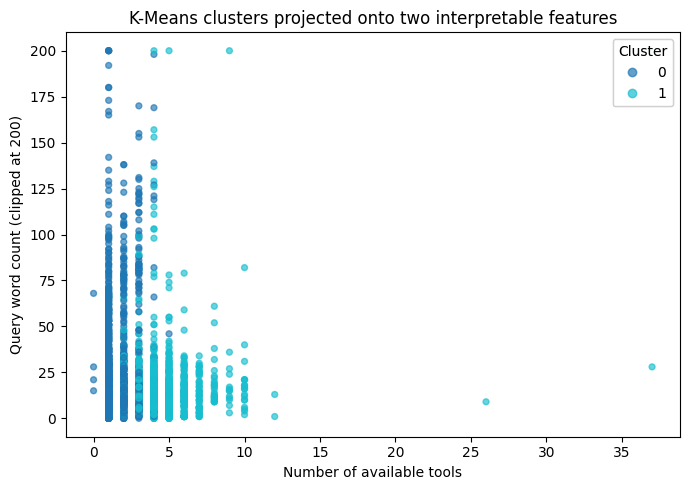

In [60]:
# 2D visualization using meaningful original features.
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df_clusters["num_available_tools"],
    df_clusters["query_word_count"].clip(upper=200),
    c=df_clusters["kmeans_cluster"],
    cmap="tab10",
    alpha=0.65,
    s=18,
)
ax.set_title("K-Means clusters projected onto two interpretable features")
ax.set_xlabel("Number of available tools")
ax.set_ylabel("Query word count (clipped at 200)")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

**Clustering discussion.**

I selected the final number of clusters using the silhouette score and checked that the clusters were interpretable with profile tables. The clusters separate tasks by query length, number of available tools, total parameter count, and live/non-live mix. Comparing clusters to `can_answer` after clustering helps interpret them, but the label was not used as a clustering input.

The clustering task is useful but less central than classification. It works best as a way to practice unsupervised thinking and feature interpretation, not as the main story of the assignment.

## Extension - Focused Clustering of Agent-Tool Situations

The generic clustering above uses the full processed feature matrix. That is valid, but it can produce broad clusters such as "short/simple" vs "long/complex." A more satisfying clustering task is to cluster **agent-tool situations** using a focused feature set tied to the assignment story.

Here I cluster with four feature families:

* query/tool alignment,
* query complexity,
* tool complexity,
* risk signals.

I still do not use `can_answer` as an input. I use it only afterward to interpret whether a cluster looks more answerable or more refusal-prone.

In [61]:
situation_features = [
    # Query/tool alignment
    "aspect_coverage_ratio",
    "aspect_overlap_count",
    "aspect_mismatch_count",
    "query_tool_token_jaccard",
    "query_tool_action_overlap",
    # Query complexity
    "query_word_count",
    "query_multi_intent_score",
    "query_specificity_score",
    "query_unique_token_ratio",
    # Tool complexity
    "num_available_tools",
    "total_params",
    "total_required_params",
    "schema_rigidity_score",
    "param_type_diversity",
    # Risk signals
    "risky_tool_action_count",
    "query_sensitive_data_signal",
    "query_code_signal",
    "query_temporal_signal",
]

X_situation = df_fe[situation_features].copy()
X_situation = X_situation.fillna(X_situation.median(numeric_only=True))
situation_scaler = StandardScaler().fit(X_situation)
X_situation_scaled = situation_scaler.transform(X_situation)
print("Focused clustering matrix:", X_situation.shape)
display(X_situation.describe().T.round(3))

Focused clustering matrix: (3491, 18)


,count,mean,std,min,25%,50%,75%,max
aspect_coverage_ratio,3491.0,0.269,0.429,0.0,0.000,0.000,0.667,1.0
aspect_overlap_count,3491.0,0.329,0.550,0.0,0.000,0.000,1.000,4.0
aspect_mismatch_count,3491.0,0.327,0.678,0.0,0.000,0.000,1.000,10.0
query_tool_token_jaccard,3491.0,0.090,0.101,0.0,0.000,0.071,0.136,1.0
query_tool_action_overlap,3491.0,0.308,0.503,0.0,0.000,0.000,1.000,5.0
query_word_count,3491.0,21.953,50.547,0.0,9.000,14.000,22.000,1436.0
query_multi_intent_score,3491.0,0.796,1.644,0.0,0.000,0.000,1.000,20.0
query_specificity_score,3491.0,2.489,11.881,0.0,0.000,1.000,2.500,364.0
query_unique_token_ratio,3491.0,0.894,0.166,0.0,0.857,0.947,1.000,1.0
num_available_tools,3491.0,2.457,2.027,0.0,1.000,2.000,3.000,37.0


,k,wcss,silhouette
0,2,55070.436,0.177
1,3,48965.241,0.184
2,4,42967.383,0.207
3,5,39059.263,0.218
4,6,36003.814,0.214
5,7,33135.493,0.170
6,8,31751.542,0.170


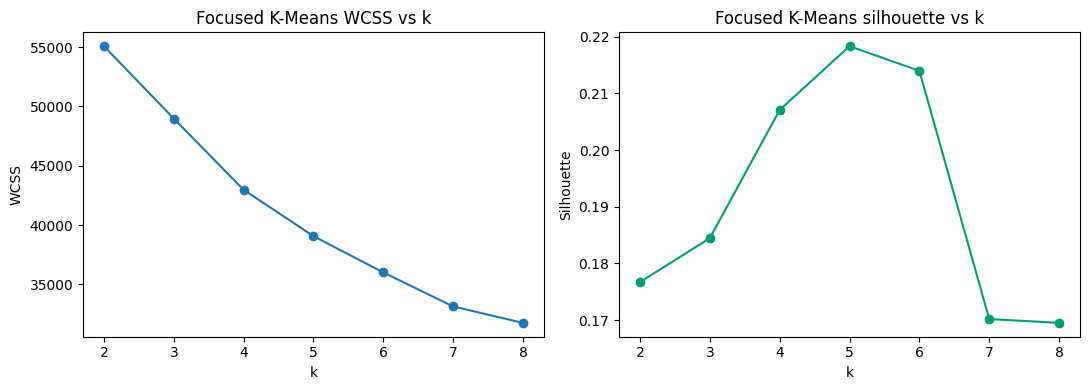

In [62]:
ks_focus = list(range(2, 9))
focus_rows = []
for k in ks_focus:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(X_situation_scaled)
    focus_rows.append({
        "k": k,
        "wcss": km.inertia_,
        "silhouette": silhouette_score(X_situation_scaled, km.labels_),
    })
focus_scores = pd.DataFrame(focus_rows)
display(focus_scores.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(focus_scores["k"], focus_scores["wcss"], marker="o")
axes[0].set_title("Focused K-Means WCSS vs k")
axes[0].set_xlabel("k")
axes[0].set_ylabel("WCSS")
axes[1].plot(focus_scores["k"], focus_scores["silhouette"], marker="o", color="#009e73")
axes[1].set_title("Focused K-Means silhouette vs k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

In [63]:
# I choose k=5 for interpretability. The silhouette curve may favor fewer
# clusters, but k=5 gives more useful situation profiles.
focused_k = 4
focused_km = KMeans(n_clusters=focused_k, n_init=30, random_state=RANDOM_STATE).fit(X_situation_scaled)
df_situations = df_fe.copy()
df_situations["situation_cluster"] = focused_km.labels_

profile_cols = situation_features + ["can_answer", "is_live_benchmark"]
situation_profile = df_situations.groupby("situation_cluster")[profile_cols].mean().round(3)
situation_profile["size"] = df_situations["situation_cluster"].value_counts().sort_index()

# Put size and answer rate first for readability.
situation_profile = situation_profile[
    ["size", "can_answer", "is_live_benchmark"]
    + [c for c in situation_profile.columns if c not in ["size", "can_answer", "is_live_benchmark"]]
]
display(situation_profile)

,size,can_answer,is_live_benchmark,aspect_coverage_ratio,aspect_overlap_count,aspect_mismatch_count,query_tool_token_jaccard,query_tool_action_overlap,query_word_count,query_multi_intent_score,query_specificity_score,query_unique_token_ratio,num_available_tools,total_params,total_required_params,schema_rigidity_score,param_type_diversity,risky_tool_action_count,query_sensitive_data_signal,query_code_signal,query_temporal_signal
situation_cluster,,,,,,,,,,,,,,,,,,,,,
0,487,0.758,0.988,0.372,0.462,0.246,0.070,0.507,19.101,0.454,1.291,0.945,5.561,23.331,13.540,0.385,2.903,1.458,0.068,0.049,0.103
1,2195,0.583,0.641,0.006,0.013,0.398,0.071,0.164,17.066,0.583,1.657,0.903,1.873,6.317,3.026,0.430,2.086,0.146,0.068,0.091,0.074
2,806,0.891,0.447,0.922,1.113,0.148,0.156,0.578,31.727,1.532,4.134,0.840,2.175,6.527,3.864,0.491,1.900,0.203,0.055,0.086,0.189
3,3,0.000,1.000,0.000,0.000,10.000,0.003,1.000,1435.333,15.000,364.000,0.285,1.000,3.000,1.667,0.389,2.000,0.000,1.000,1.000,1.000


In [64]:
def name_situation_cluster(row):
    if row["aspect_coverage_ratio"] >= 0.55 and row["query_tool_token_jaccard"] >= 0.10:
        return "clear semantic match"
    if row["query_sensitive_data_signal"] >= 0.20 or row["query_code_signal"] >= 0.20:
        return "sensitive/code-heavy weak match"
    if row["query_multi_intent_score"] >= 2.0 or row["query_word_count"] >= 60:
        return "complex multi-intent request"
    if row["num_available_tools"] >= 4 or row["total_params"] >= 15:
        return "tool-heavy situation"
    if row["aspect_coverage_ratio"] <= 0.05 and row["aspect_mismatch_count"] >= 0.5:
        return "weak semantic match"
    return "simple low-signal situation"

cluster_names = situation_profile.apply(name_situation_cluster, axis=1)
profile_table = situation_profile[[
    "size",
    "can_answer",
    "aspect_coverage_ratio",
    "aspect_mismatch_count",
    "query_tool_token_jaccard",
    "query_multi_intent_score",
    "num_available_tools",
    "risky_tool_action_count",
    "query_sensitive_data_signal",
    "query_code_signal",
]].copy()
profile_table.insert(1, "descriptive_name", cluster_names)
profile_table = profile_table.rename(columns={"can_answer": "answer_rate"})
display(profile_table)

print("Cluster vs target counts:")
display(pd.crosstab(df_situations["situation_cluster"], df_situations["can_answer"]))
print("Cluster vs task complexity:")
display(pd.crosstab(df_situations["situation_cluster"], df_situations["task_complexity"], normalize="index").round(3))

,size,descriptive_name,answer_rate,aspect_coverage_ratio,aspect_mismatch_count,query_tool_token_jaccard,query_multi_intent_score,num_available_tools,risky_tool_action_count,query_sensitive_data_signal,query_code_signal
situation_cluster,,,,,,,,,,,
0,487,tool-heavy situation,0.758,0.372,0.246,0.070,0.454,5.561,1.458,0.068,0.049
1,2195,simple low-signal situation,0.583,0.006,0.398,0.071,0.583,1.873,0.146,0.068,0.091
2,806,clear semantic match,0.891,0.922,0.148,0.156,1.532,2.175,0.203,0.055,0.086
3,3,sensitive/code-heavy weak match,0.000,0.000,10.000,0.003,15.000,1.000,0.000,1.000,1.000


Cluster vs target counts:


can_answer,0,1
situation_cluster,,
0,118,369
1,915,1280
2,88,718
3,3,0


Cluster vs task complexity:


task_complexity,high,low,medium
situation_cluster,,,
0,1.000,0.000,0.000
1,0.207,0.424,0.369
2,0.273,0.289,0.438
3,1.000,0.000,0.000


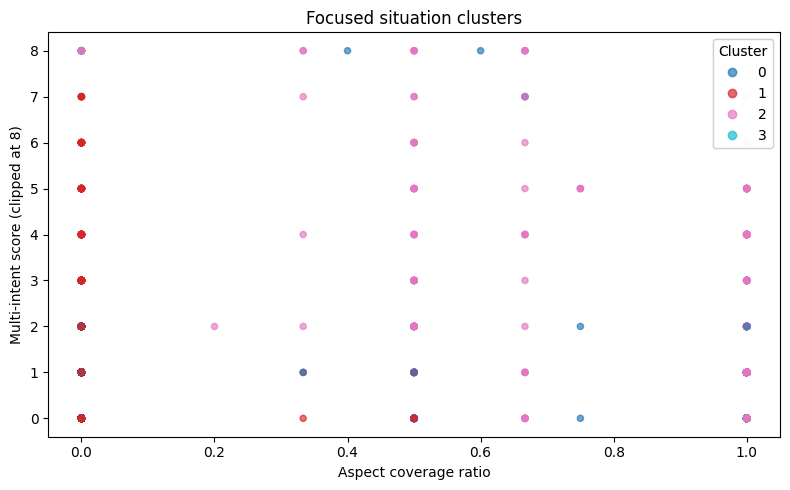

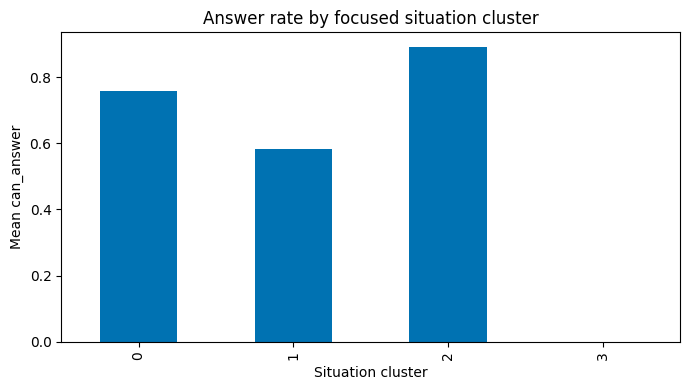

In [65]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    df_situations["aspect_coverage_ratio"],
    df_situations["query_multi_intent_score"].clip(upper=8),
    c=df_situations["situation_cluster"],
    cmap="tab10",
    s=20,
    alpha=0.65,
)
ax.set_title("Focused situation clusters")
ax.set_xlabel("Aspect coverage ratio")
ax.set_ylabel("Multi-intent score (clipped at 8)")
legend = ax.legend(*scatter.legend_elements(), title="Cluster", loc="upper right")
ax.add_artist(legend)
plt.tight_layout()
plt.show()

answer_rates = df_situations.groupby("situation_cluster")["can_answer"].mean().sort_index()
ax = answer_rates.plot(kind="bar", color="#0072b2", figsize=(7, 4))
ax.set_title("Answer rate by focused situation cluster")
ax.set_xlabel("Situation cluster")
ax.set_ylabel("Mean can_answer")
plt.tight_layout()
plt.show()

**Focused clustering discussion.**

This version is more satisfying than clustering on every available feature. The clusters have clearer interpretations because the input features were chosen around the agent-tool situation:

* semantic match vs mismatch,
* simple vs multi-intent query,
* tool-light vs tool-heavy setup,
* ordinary vs sensitive/code-heavy requests.

The cluster names are heuristic, but the profile table makes the reasoning visible. This is the type of clustering task I would recommend for the final assignment: students should not just report `k`; they should name the situations and explain why the clusters matter for tool-use decisions.

## Final Notebook Summary

In [66]:
final_summary = pd.DataFrame([
    {
        "Item": "Best model",
        "Result": best_name,
    },
    {
        "Item": "Main metric",
        "Result": "F1-score for the refusal class (can_answer = 0)",
    },
    {
        "Item": "Best test refusal F1",
        "Result": round(float(test_results.loc[best_name, "f1_refuse_0"]), 4),
    },
    {
        "Item": "Best test accuracy",
        "Result": round(float(test_results.loc[best_name, "accuracy"]), 4),
    },
    {
        "Item": "Most important practical error",
        "Result": "False positive: the agent calls a tool when it should refuse.",
    },
    {
        "Item": "Dataset limitation",
        "Result": "The target is derived from benchmark construction, and task_domain is keyword-derived.",
    },
    {
        "Item": "Suggested improvement",
        "Result": "Add manually reviewed relevance labels and richer semantic features for queries/tools.",
    },
])
display(final_summary)

,Item,Result
0,Best model,AdaBoost
1,Main metric,F1-score for the refusal class (can_answer = 0)
2,Best test refusal F1,0.7805
3,Best test accuracy,0.8714
4,Most important practical error,False positive: the agent calls a tool when it...
5,Dataset limitation,The target is derived from benchmark construct...
6,Suggested improvement,Add manually reviewed relevance labels and ric...


## Assignment Feedback After Solving

**What worked well.**

The assignment is coherent as a machine-learning task. The central question is concrete: should the agent call a tool or refuse? The dataset is small enough to run quickly, but rich enough to support meaningful EDA, feature engineering, model comparison, and clustering.

The new semantic/aspect features make the solution more interesting than the earlier simple-count dataset. Students can reason about why `aspect_coverage_ratio`, `query_tool_token_jaccard`, sensitive-data signals, and action-overlap features might matter. This encourages interpretation rather than just plugging columns into models.

**What was challenging.**

The one-hot encoding of `query_aspects` and `tool_aspects` creates many columns. This is manageable, but students need to understand why categorical encoding can increase dimensionality. The assignment should keep reminding them that raw text fields are not direct numeric model inputs.

The clustering section is feasible, but it is less compelling than the classification section. The clusters are interpretable, but not as central to the agent-refusal problem. Keeping clustering at 15 points feels appropriate.

**Recommended assignment refinements.**

* Keep the new semantic/aspect feature set.
* Keep AdaBoost as the required boosting model; it performs well and makes the model comparison more interesting.
* Keep the instruction that oversampling is optional, not required.
* Consider adding one sentence in the assignment saying that `query_aspects` and `tool_aspects` may be encoded, simplified, or excluded, as long as the choice is justified.
* Do not restore the API/join section; it would distract from the clearer ML story.

Overall, the solution is interesting enough for students: the baseline fails on refusals, AdaBoost improves substantially, and the semantic features give students something meaningful to discuss.